In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error


In [2]:
import joblib

lasso_model = joblib.load('models/lasso_final_model.pkl')

In [3]:
#Loading in dataset and setting index
model_data = pd.read_csv('processed/model_data.csv', index_col=0, parse_dates=True)
model_data['year'] = model_data.index.year
numeric_features = model_data.select_dtypes(include='number').columns.tolist()


In [4]:
regions = model_data['region'].unique()
lasso_features = list(lasso_model.feature_names_in_)
results = []

for region in regions:
    region_data = model_data[model_data['region'] == region].dropna()
    test = region_data[region_data.index >= '2022-01-01']
    
    if test.empty:
        continue

    X_test = test[lasso_features]
    y_test = test['median']

    y_pred = lasso_model.predict(X_test)

    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        'region': region,
        'MAPE': round(mape, 2),
        'RMSE': round(rmse, 2)
    })

results_df = pd.DataFrame(results).sort_values('MAPE')
results_df


,region,MAPE,RMSE
0,England,0.47,1870.83
1,North East,0.75,1619.23
4,East Midlands,0.87,2932.01
5,West Midlands,0.92,3433.76
7,London,0.97,12072.61
3,Yorkshire and The Humber,1.00,2584.34
9,South West,1.03,6296.63
8,South East,1.04,6114.14
2,North West,1.05,2923.27
6,East of England,1.10,6231.08


In [5]:
local_authorities = model_data['LA'].unique()
lasso_features = list(lasso_model.feature_names_in_)
results = []

for local_authority in local_authorities:
    local_authority_data = model_data[model_data['LA'] == local_authority].dropna()
    test = local_authority_data[local_authority_data.index >= '2022-01-01']
    
    if test.empty:
        continue

    X_test = test[lasso_features]
    y_test = test['median']

    y_pred = lasso_model.predict(X_test)

    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        'LA': local_authority,
        'MAPE': round(mape, 2),
        'RMSE': round(rmse, 2)
    })

results_df = pd.DataFrame(results).sort_values('MAPE')
results_df

,LA,MAPE,RMSE
189,Hillingdon,0.18,1053.43
198,Redbridge,0.23,1463.87
120,Wyre Forest,0.25,787.54
64,Leicester,0.26,787.42
236,Canterbury,0.27,1197.59
...,...,...,...
21,Burnley,2.69,3499.37
205,Westminster,2.75,34467.76
100,Stoke-on-Trent,2.90,4211.19
192,Kensington and Chelsea,3.13,43690.48


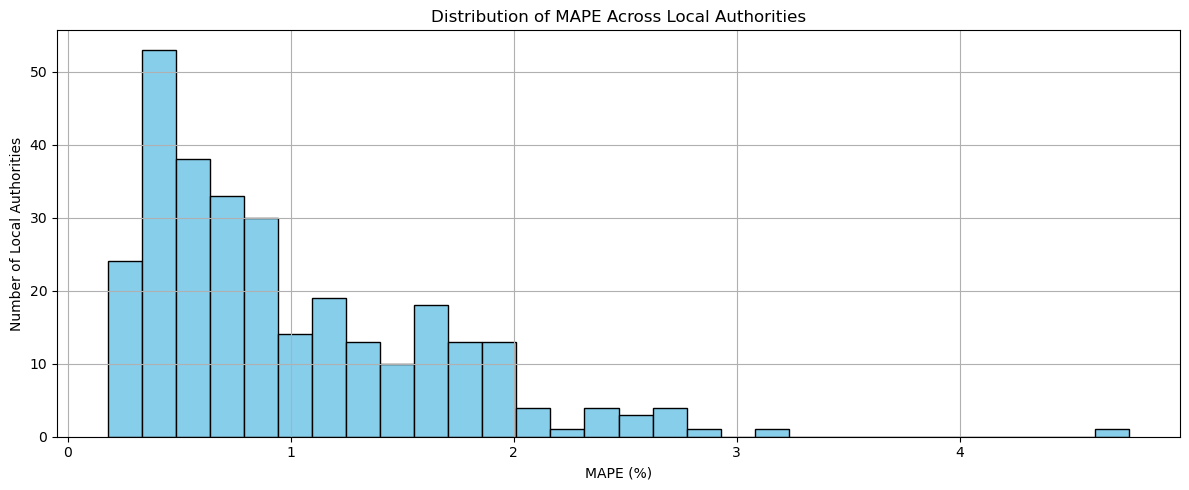

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.hist(results_df['MAPE'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of MAPE Across Local Authorities')
plt.xlabel('MAPE (%)')
plt.ylabel('Number of Local Authorities')
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
def create_features(df):
    df = df.copy() 
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    return df

def add_lags(df, lags=12):
    df = df.copy()
    for lag in range(1, lags + 1):
        df[f'lag_{lag}'] = df['median'].shift(lag)
    return df

In [8]:
model_data.index.max()

Timestamp('2024-03-01 00:00:00')

In [9]:
# Create future dataframe
future = pd.date_range('2024-03-01','2024-06-01', freq='MS')
future_df = pd.DataFrame(index=future)
future_df['isFuture'] = True
model_data['isFuture'] = False
df_and_future = pd.concat([model_data, future_df])
df_and_future = create_features(df_and_future)
df_and_future = add_lags(df_and_future)

In [10]:
future_w_features = df_and_future.query('isFuture').copy()

In [14]:
missing_summary = future_w_features[lasso_features].isna().sum()
print("Missing values per feature in future predictions:")
print(missing_summary[missing_summary > 0])


Missing values per feature in future predictions:
average    4
hpi        4
change     4
base       4
5year      4
2year      4
revert     4
cpih       4
lag_1      3
lag_2      2
lag_3      1
dtype: int64
